In [1]:
# Import required libraries

import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Performance Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# Save Model
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("cardio_train.csv", sep=";")

In [3]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [4]:
df.tail()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1
69999,99999,20540,1,170,72.0,120,80,2,1,0,0,1,0


In [5]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 70000
Number of Columns : 13


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [7]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
df.dtypes

,0
id,int64
age,int64
gender,int64
height,int64
weight,float64
ap_hi,int64
ap_lo,int64
cholesterol,int64
gluc,int64
smoke,int64


In [9]:
df.isnull().sum()

,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


In [10]:
print(df.duplicated().sum())

0


In [11]:
df.drop("id", axis=1, inplace=True)

In [12]:
df["age"] = df["age"] / 365

In [13]:
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50.391781,2,168,62.0,110,80,1,1,0,0,1,0
1,55.419178,1,156,85.0,140,90,3,1,0,0,1,1
2,51.663014,1,165,64.0,130,70,3,1,0,0,0,1
3,48.282192,2,169,82.0,150,100,1,1,0,0,1,1
4,47.873973,1,156,56.0,100,60,1,1,0,0,0,0


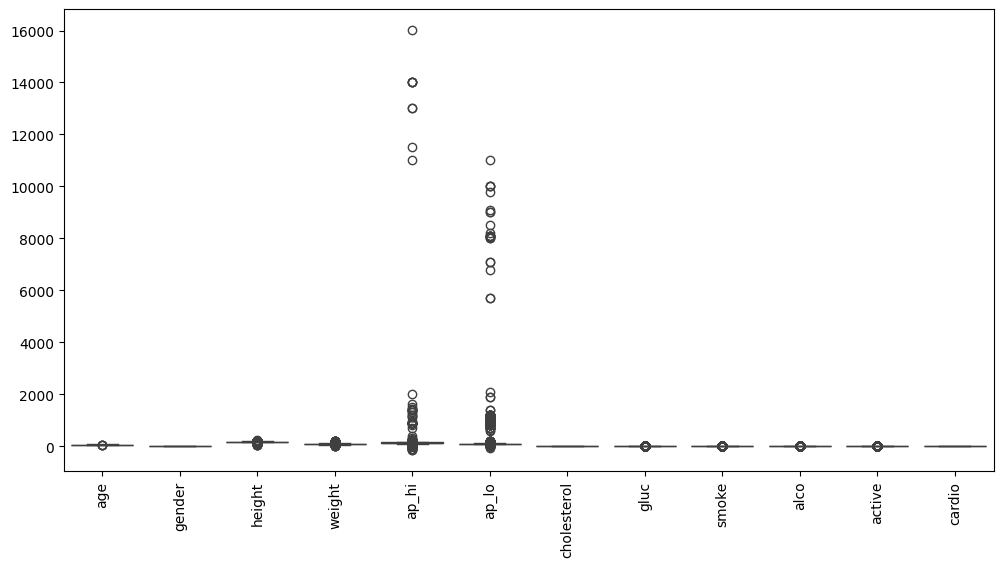

In [14]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [15]:
df = df[(df['height'] > 120) & (df['height'] < 220)]
df = df[(df['weight'] > 30) & (df['weight'] < 200)]

In [16]:
df.shape

(69902, 12)

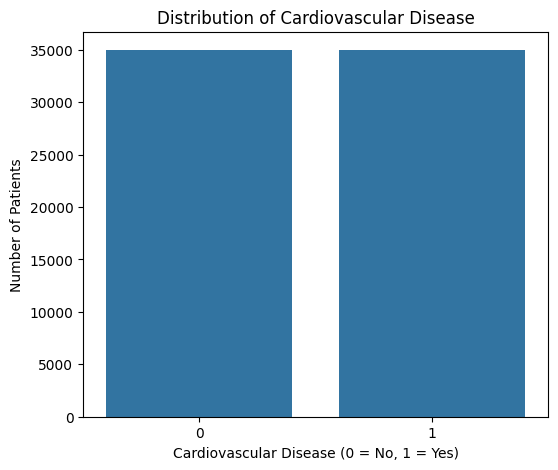

cardio
0    34970
1    34932
Name: count, dtype: int64


In [17]:
plt.figure(figsize=(6,5))
sns.countplot(x='cardio', data=df)
plt.title("Distribution of Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.show()

print(df['cardio'].value_counts())

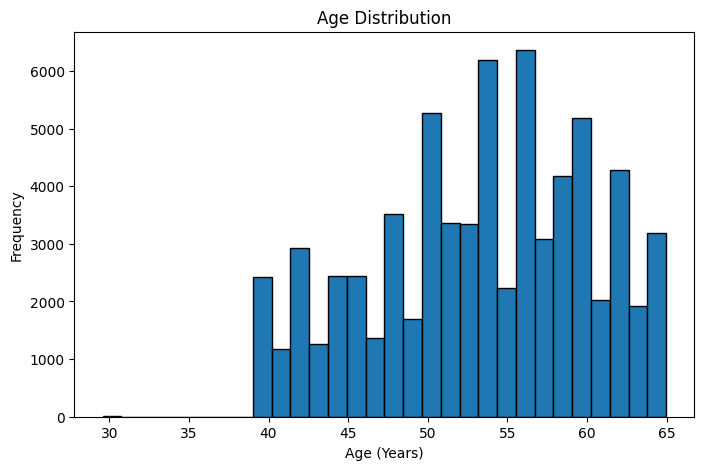

In [18]:
plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=30, edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age (Years)")
plt.ylabel("Frequency")
plt.show()

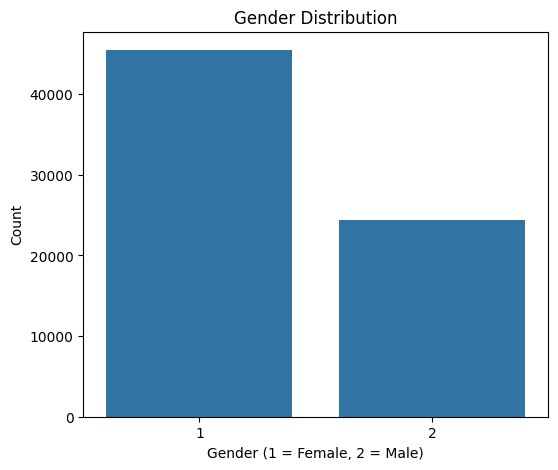

In [19]:
plt.figure(figsize=(6,5))
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender (1 = Female, 2 = Male)")
plt.ylabel("Count")
plt.show()

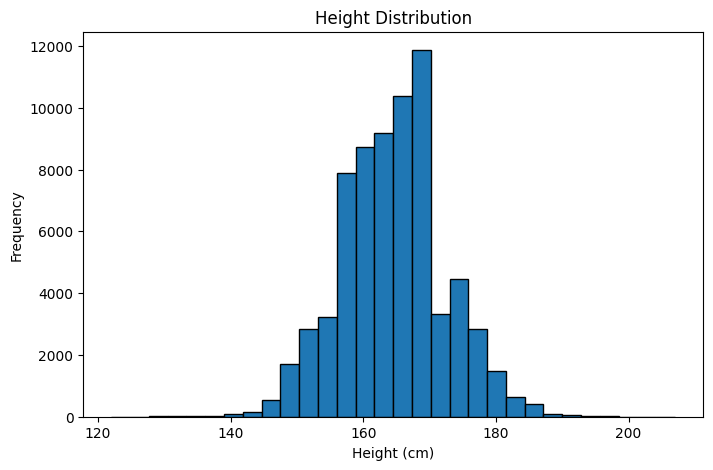

In [20]:
plt.figure(figsize=(8,5))
plt.hist(df['height'], bins=30, edgecolor='black')
plt.title("Height Distribution")
plt.xlabel("Height (cm)")
plt.ylabel("Frequency")
plt.show()

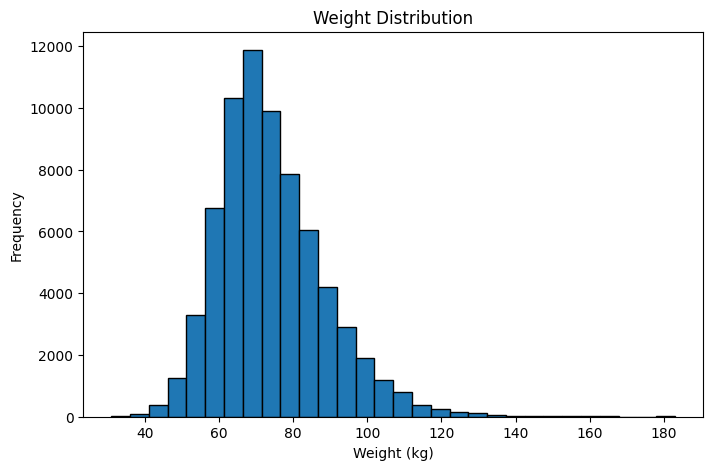

In [21]:
plt.figure(figsize=(8,5))
plt.hist(df['weight'], bins=30, edgecolor='black')
plt.title("Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")
plt.show()

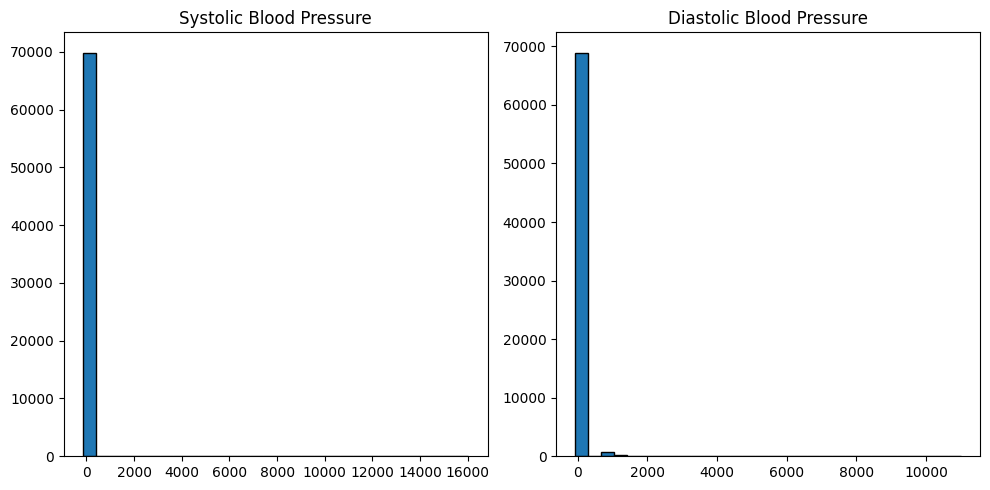

In [22]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.hist(df['ap_hi'], bins=30, edgecolor='black')
plt.title("Systolic Blood Pressure")

plt.subplot(1,2,2)
plt.hist(df['ap_lo'], bins=30, edgecolor='black')
plt.title("Diastolic Blood Pressure")

plt.tight_layout()
plt.show()

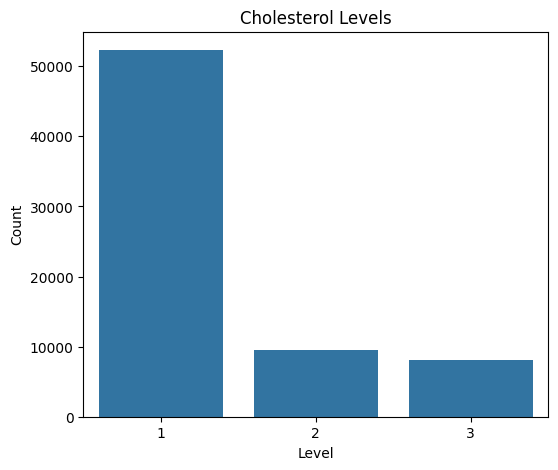

In [23]:
plt.figure(figsize=(6,5))
sns.countplot(x='cholesterol', data=df)
plt.title("Cholesterol Levels")
plt.xlabel("Level")
plt.ylabel("Count")
plt.show()

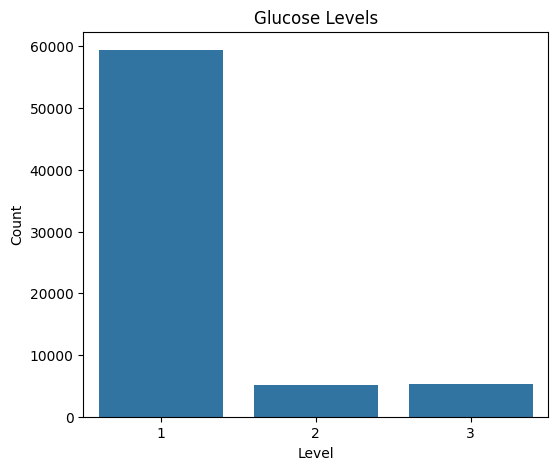

In [24]:
plt.figure(figsize=(6,5))
sns.countplot(x='gluc', data=df)
plt.title("Glucose Levels")
plt.xlabel("Level")
plt.ylabel("Count")
plt.show()

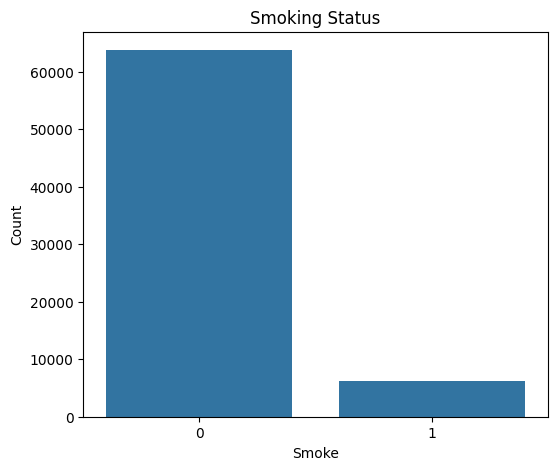

In [25]:
plt.figure(figsize=(6,5))
sns.countplot(x='smoke', data=df)
plt.title("Smoking Status")
plt.xlabel("Smoke")
plt.ylabel("Count")
plt.show()

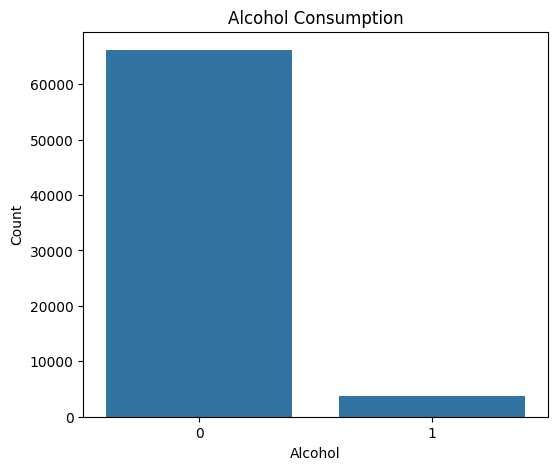

In [26]:
plt.figure(figsize=(6,5))
sns.countplot(x='alco', data=df)
plt.title("Alcohol Consumption")
plt.xlabel("Alcohol")
plt.ylabel("Count")
plt.show()

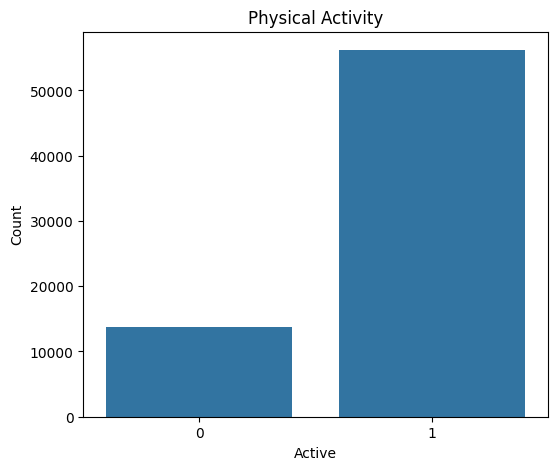

In [27]:
plt.figure(figsize=(6,5))
sns.countplot(x='active', data=df)
plt.title("Physical Activity")
plt.xlabel("Active")
plt.ylabel("Count")
plt.show()

In [28]:
df['BMI'] = df['weight'] / ((df['height']/100)**2)

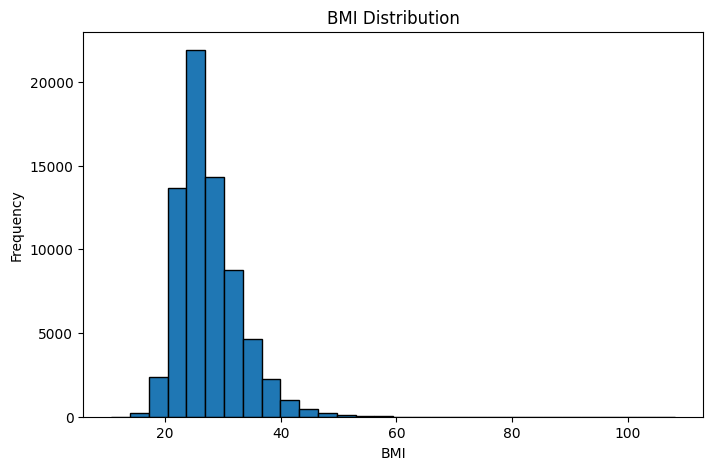

In [29]:
plt.figure(figsize=(8,5))
plt.hist(df['BMI'], bins=30, edgecolor='black')
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

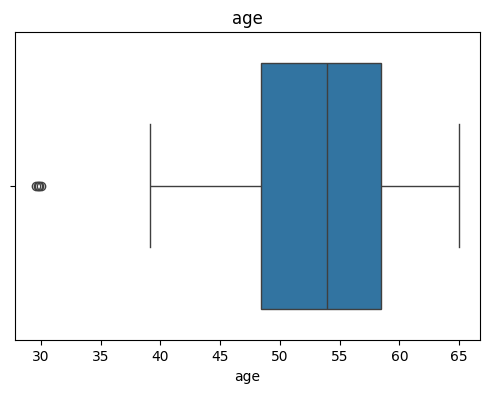

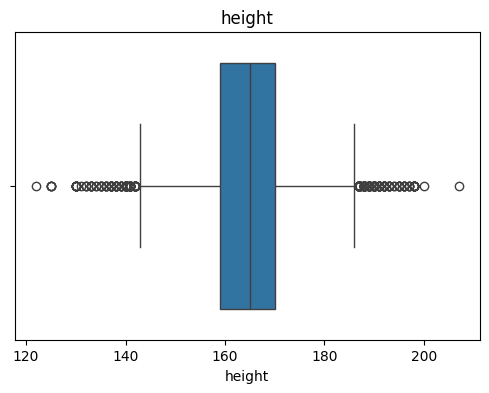

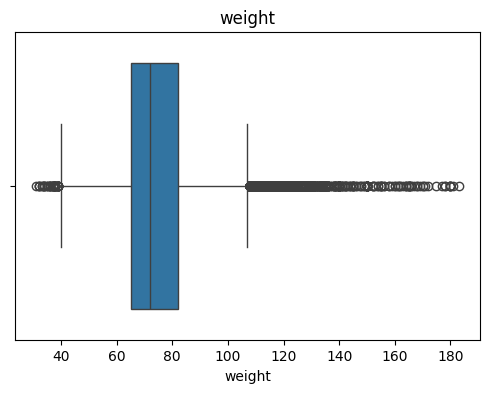

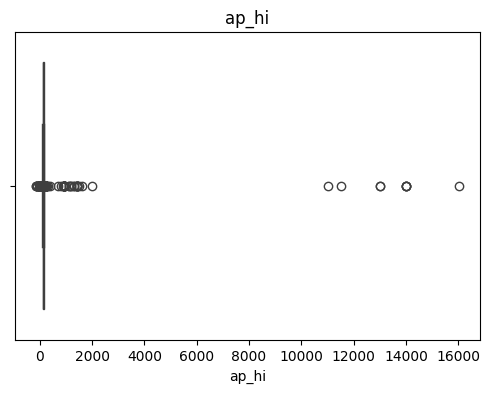

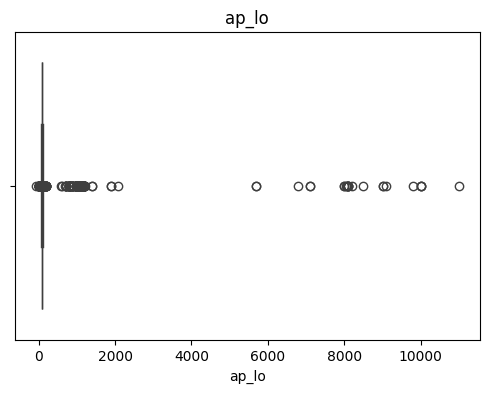

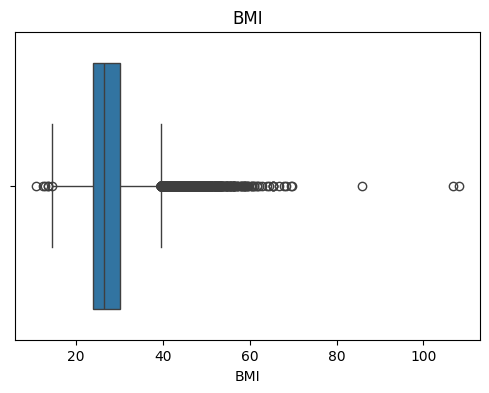

In [30]:
numerical = ['age','height','weight','ap_hi','ap_lo','BMI']

for col in numerical:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

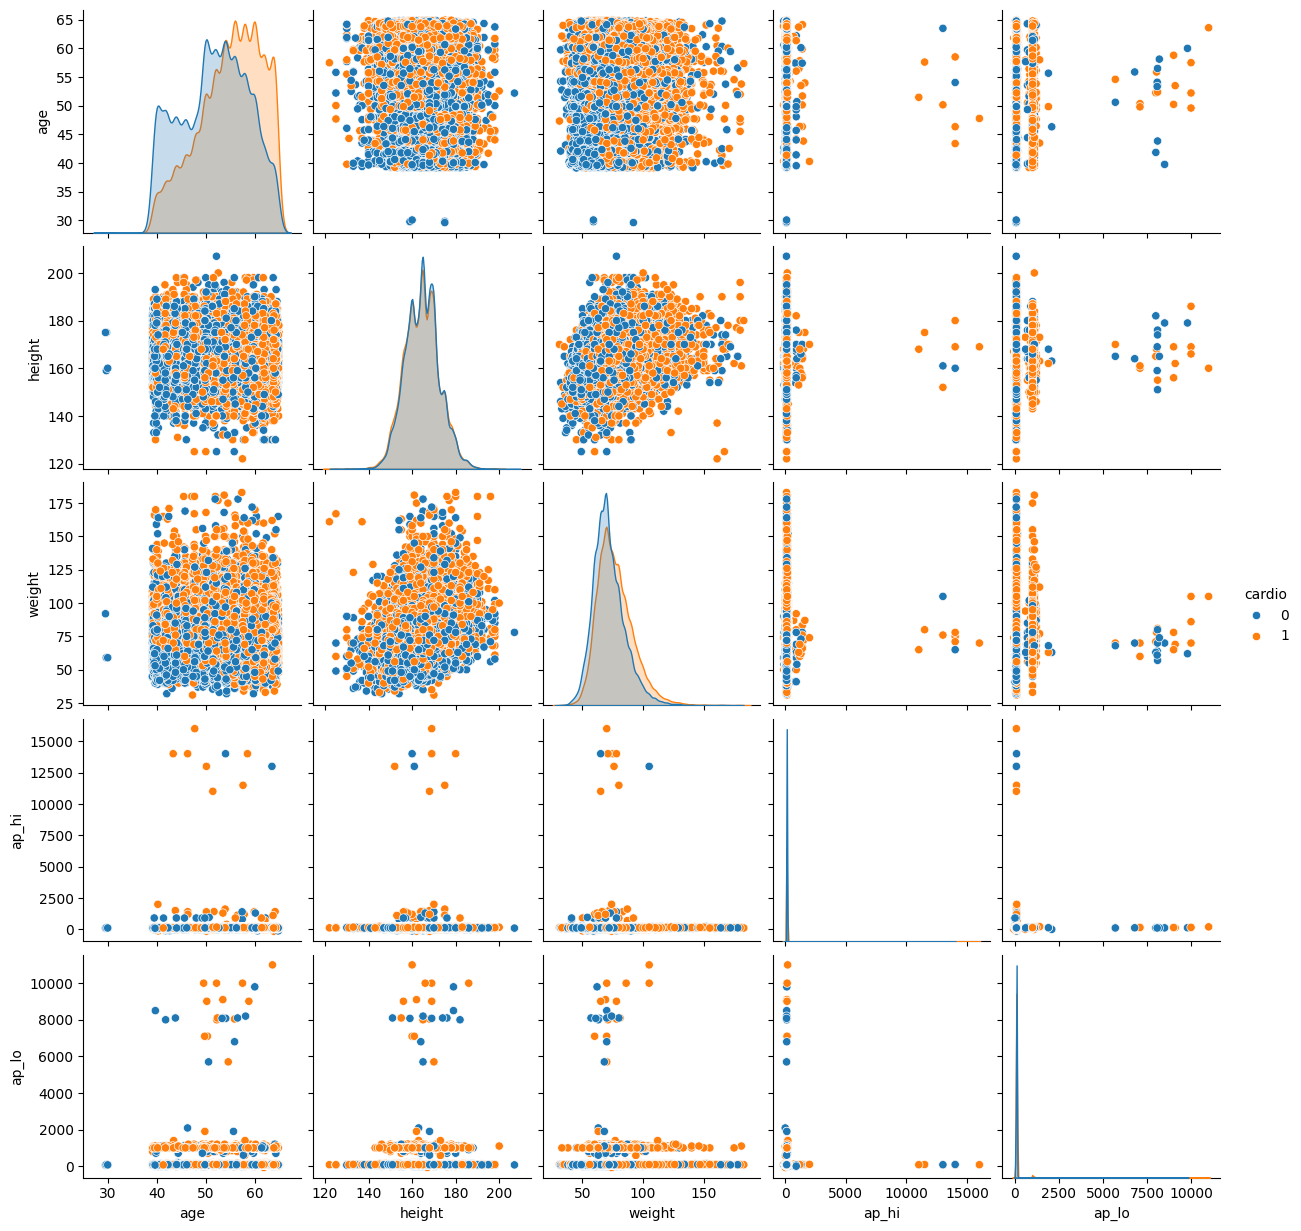

In [31]:
selected_features = ['age','height','weight','ap_hi','ap_lo','cardio']

sns.pairplot(df[selected_features], hue='cardio')
plt.show()

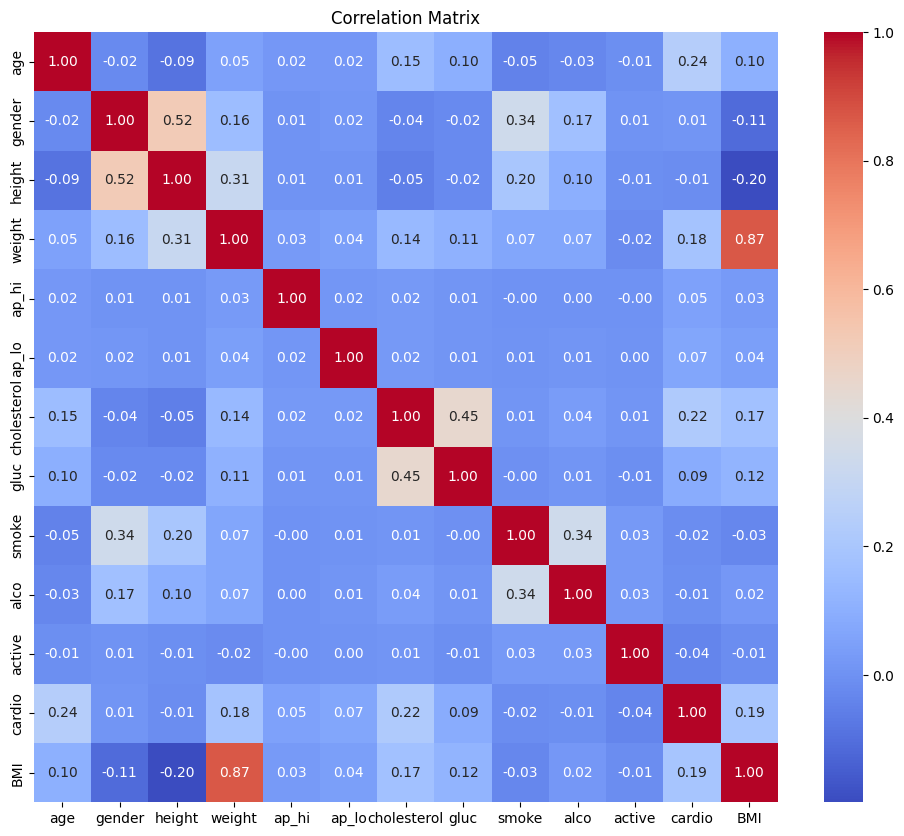

In [32]:
plt.figure(figsize=(12,10))

corr = df.corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Matrix")
plt.show()

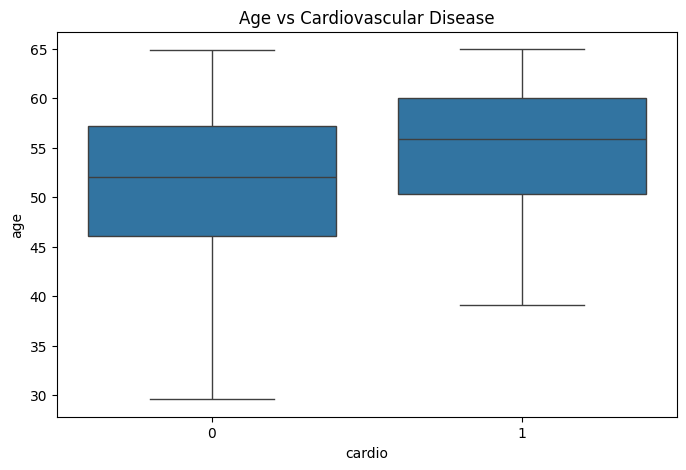

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(x='cardio',
            y='age',
            data=df)

plt.title("Age vs Cardiovascular Disease")

plt.show()

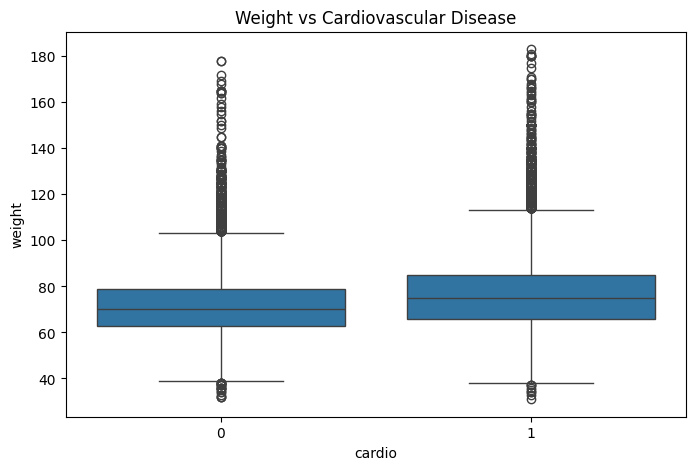

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(x='cardio',
            y='weight',
            data=df)

plt.title("Weight vs Cardiovascular Disease")

plt.show()

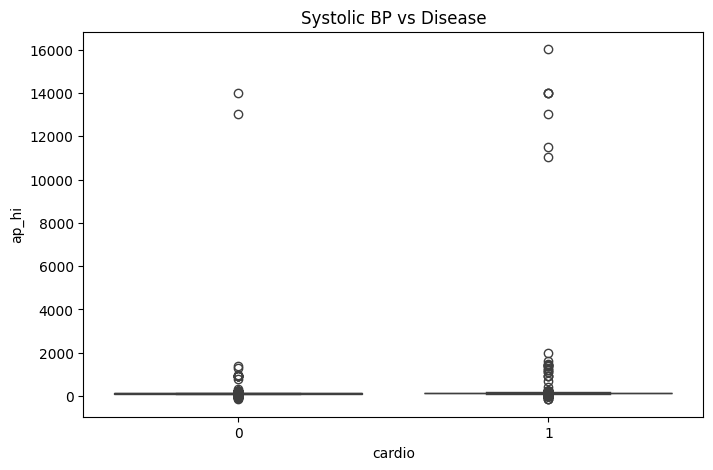

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(x='cardio',
            y='ap_hi',
            data=df)

plt.title("Systolic BP vs Disease")

plt.show()

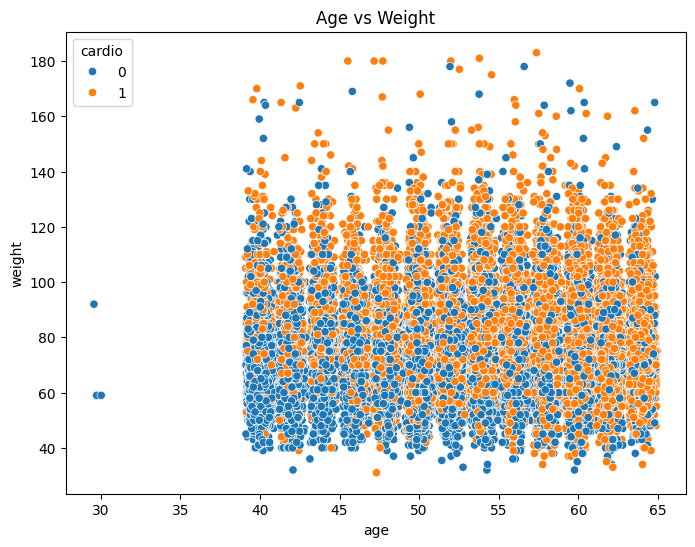

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='age',
                y='weight',
                hue='cardio',
                data=df)

plt.title("Age vs Weight")

plt.show()

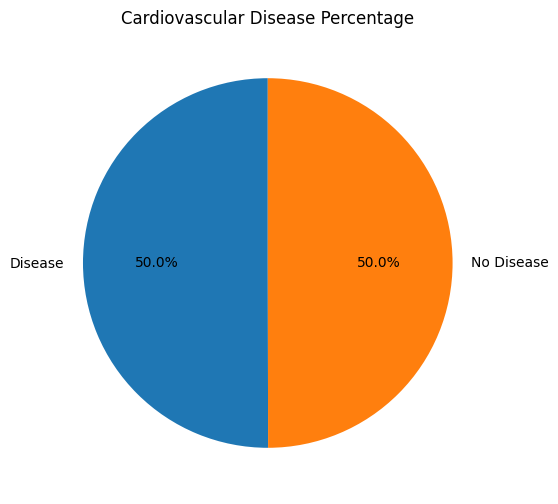

In [37]:
counts = df['cardio'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(counts,
        labels=['Disease','No Disease'],
        autopct='%1.1f%%',
        startangle=90)

plt.title("Cardiovascular Disease Percentage")

plt.show()

In [38]:
X = df.drop('cardio', axis=1)
y = df['cardio']

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (55921, 12)
Testing Data : (13981, 12)


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(random_state=42)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", round(lr_accuracy*100,2),"%")

Logistic Regression Accuracy: 71.52 %


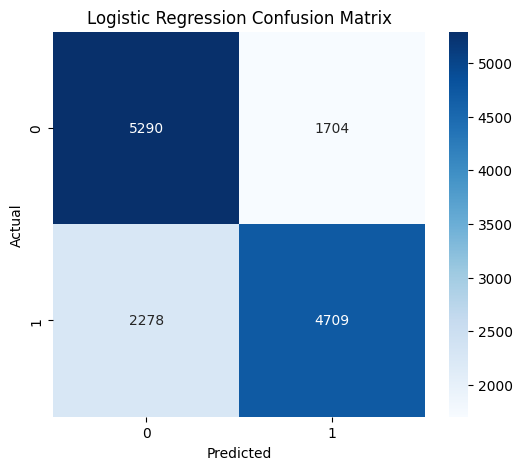

In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.70      0.76      0.73      6994
           1       0.73      0.67      0.70      6987

    accuracy                           0.72     13981
   macro avg       0.72      0.72      0.71     13981
weighted avg       0.72      0.72      0.71     13981



In [44]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,y_train)

y_pred_knn = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test,y_pred_knn)

print("KNN Accuracy:", round(knn_accuracy*100,2),"%")

KNN Accuracy: 64.04 %


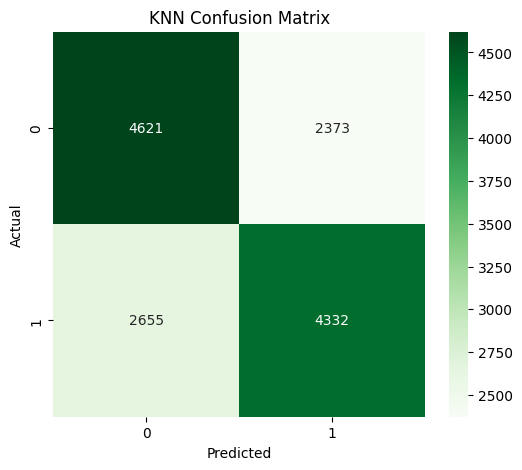

In [45]:
cm = confusion_matrix(y_test,y_pred_knn)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

In [46]:
print(classification_report(y_test,y_pred_knn))

              precision    recall  f1-score   support

           0       0.64      0.66      0.65      6994
           1       0.65      0.62      0.63      6987

    accuracy                           0.64     13981
   macro avg       0.64      0.64      0.64     13981
weighted avg       0.64      0.64      0.64     13981



In [47]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

y_pred_dt = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test,y_pred_dt)

print("Decision Tree Accuracy:", round(dt_accuracy*100,2),"%")

Decision Tree Accuracy: 62.77 %


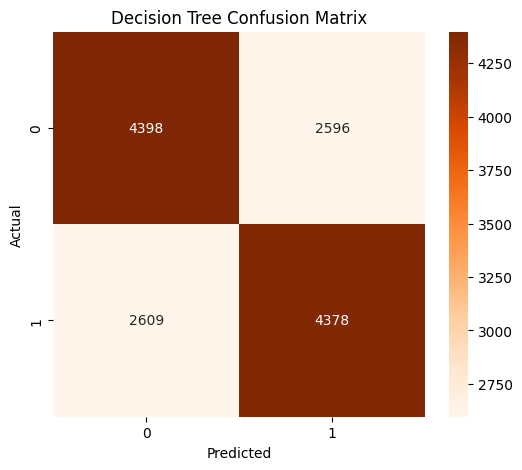

In [48]:
cm = confusion_matrix(y_test,y_pred_dt)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Oranges')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [49]:
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       0.63      0.63      0.63      6994
           1       0.63      0.63      0.63      6987

    accuracy                           0.63     13981
   macro avg       0.63      0.63      0.63     13981
weighted avg       0.63      0.63      0.63     13981



In [50]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test,y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy*100,2),"%")

Random Forest Accuracy: 70.85 %


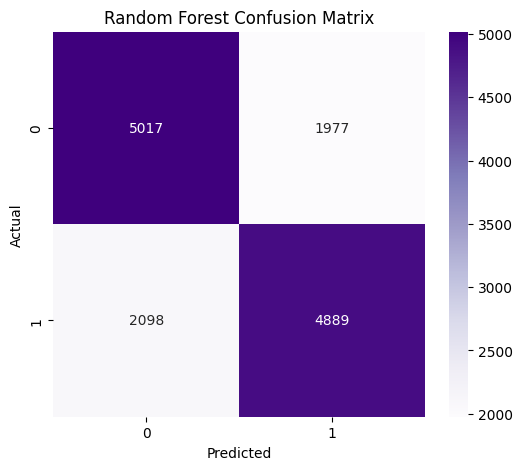

In [51]:
cm = confusion_matrix(y_test,y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Purples')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [52]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.71      0.72      0.71      6994
           1       0.71      0.70      0.71      6987

    accuracy                           0.71     13981
   macro avg       0.71      0.71      0.71     13981
weighted avg       0.71      0.71      0.71     13981



In [53]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', random_state=42)

svm.fit(X_train,y_train)

y_pred_svm = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test,y_pred_svm)

print("SVM Accuracy:", round(svm_accuracy*100,2),"%")

SVM Accuracy: 72.12 %


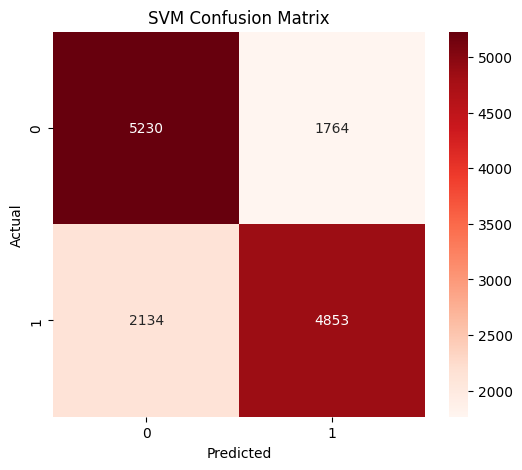

In [54]:
cm = confusion_matrix(y_test,y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Reds')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

In [55]:
print(classification_report(y_test,y_pred_svm))

              precision    recall  f1-score   support

           0       0.71      0.75      0.73      6994
           1       0.73      0.69      0.71      6987

    accuracy                           0.72     13981
   macro avg       0.72      0.72      0.72     13981
weighted avg       0.72      0.72      0.72     13981



In [56]:
result = pd.DataFrame({

    'Model':[
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest',
        'SVM'
    ],

    'Accuracy (%)':[

        lr_accuracy*100,
        knn_accuracy*100,
        dt_accuracy*100,
        rf_accuracy*100,
        svm_accuracy*100

    ]

})

result = result.sort_values(
    by='Accuracy (%)',
    ascending=False
)

result

,Model,Accuracy (%)
4,SVM,72.119305
0,Logistic Regression,71.518489
3,Random Forest,70.853301
1,KNN,64.036907
2,Decision Tree,62.770903


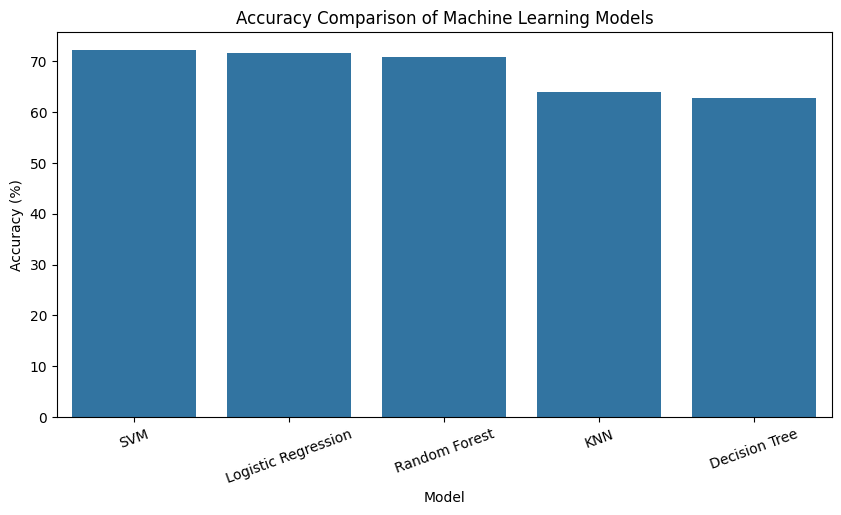

In [57]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='Accuracy (%)',
    data=result
)

plt.title("Accuracy Comparison of Machine Learning Models")

plt.xticks(rotation=20)

plt.show()

In [58]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({

    'Feature':X.columns,

    'Importance':importance

})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
0,age,0.259931
4,ap_hi,0.172226
11,BMI,0.158764
3,weight,0.114149
2,height,0.109374
5,ap_lo,0.086439
6,cholesterol,0.038310
7,gluc,0.015968
1,gender,0.015760
10,active,0.013454


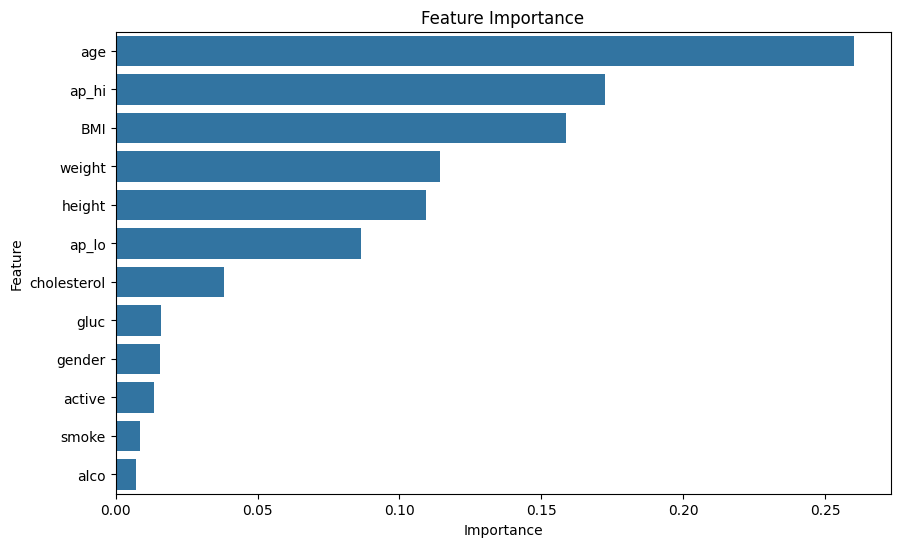

In [59]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

In [60]:
import joblib

joblib.dump(rf, "heart_disease_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [61]:
model = joblib.load("heart_disease_model.pkl")

scaler = joblib.load("scaler.pkl")

In [62]:
new_patient = pd.DataFrame([{
    'age': 50,
    'gender': 2,
    'height': 170,
    'weight': 70,
    'ap_hi': 120,
    'ap_lo': 80,
    'cholesterol': 1,
    'gluc': 1,
    'smoke': 0,
    'alco': 0,
    'active': 1,
    'BMI': 70 / ((170/100)**2)
}])

new_patient_scaled = scaler.transform(new_patient)

prediction = model.predict(new_patient_scaled)

if prediction[0] == 1:
    print("High Risk of Cardiovascular Disease")
else:
    print("Low Risk of Cardiovascular Disease")

High Risk of Cardiovascular Disease
